In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error as RMSE
from sklearn.metrics import mean_absolute_percentage_error as MAPE

In [2]:
# Then in modeling notebook
train = pd.read_csv("C:\\Users\\Mr.Zabit\\Documents\\ml_projects\\bike_rental_project\\data\\processed\\train.csv")
test = pd.read_csv("C:\\Users\\Mr.Zabit\\Documents\\ml_projects\\bike_rental_project\\data\\processed\\test.csv")

# Linear Regression

In [3]:
# Define features
categorical_features = [
    'season', 'yr', 'mnth', 'hr',
    'holiday', 'weekday', 'workingday', 'weathersit'
]

numeric_features = ['temp', 'atemp', 'hum', 'windspeed']

X_train = train[categorical_features + numeric_features]
y_train = train['cnt']

X_test = test[categorical_features + numeric_features]
y_test = test['cnt']

In [4]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

# Full pipeline
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regression', LinearRegression())
])

In [5]:
# Train
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

## Model Evaluation

In [6]:
# Predict
y_pred = model.predict(X_test)
print("MAE:", round(MAE(y_test.values, y_pred), 2))
print("RMSE:", round(RMSE(y_test.values, y_pred), 2))
print("R2:", round(r2_score(y_test.values, y_pred), 2))
print("MAPE:", round(MAPE(y_test.values, y_pred), 2))

MAE: 100.9
RMSE: 135.12
R2: 0.62
MAPE: 2.19


In [7]:
# Get feature names after one-hot encoding
feature_names = model.named_steps['preprocessing'].get_feature_names_out()

# Get coefficients
coefficients = model.named_steps['regression'].coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

In [8]:
# Top positive
print("======== Top positive coefficients:")
print(coef_df.sort_values(by='coefficient', ascending=False).head(3))

# Top negative
print("\n======== Top negative coefficients:")
print(coef_df.sort_values(by='coefficient').head(3))

======== Top positive coefficients:
       feature  coefficient
31  cat__hr_17   335.251191
32  cat__hr_18   308.986357
22   cat__hr_8   275.451925

======== Top negative coefficients:
              feature  coefficient
51           num__hum   -70.936211
47  cat__weathersit_3   -64.636297
48  cat__weathersit_4   -58.085137


## Questions

1. What is the linear model assuming about relationships between features and cnt?

The linear model thinks that each thing we use to predict (like hour, weather, or temperature) adds or reduces a fixed number of bike rentals.

2. Which coefficients match your intuition? Which do not? 

Hours increase rentals, bad weather and high humidity decrease rentals — these coefficients match intuition.

# Regularization: Ridge and Lasso


In [9]:
categorical_features = [
    'season', 'yr', 'mnth', 'hr',
    'holiday', 'weekday', 'workingday', 'weathersit'
]
numeric_features = ['temp', 'atemp', 'hum', 'windspeed']

# Preprocessing using Label/Ordinal encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

# Linear regression pipeline
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regression', LinearRegression())
])

In [10]:
# Ridge
ridge_model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('ridge', RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5))
])

# Lasso
lasso_model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('lasso', LassoCV(alphas=[0.01, 0.1, 1.0], cv=5, max_iter=5000))
])

In [11]:
# Train
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

# Predict
y_ridge = ridge_model.predict(X_test)
y_lasso = lasso_model.predict(X_test)

# Evaluate
print("======== Ridge Evaluation =======")
print("Ridge MAE: ",  round(MAE(y_test.values, y_ridge), 2))
print("Ridge RMSE:", round(RMSE(y_test.values, y_ridge), 2))
print("Ridge R2:  ",   round(r2_score(y_test.values, y_ridge), 2))
print("Ridge MAPE:", round(MAPE(y_test.values, y_ridge), 2))
print("\n======== Lasso Evaluation =======")
print("Lasso MAE: ",  round(MAE(y_test.values, y_lasso), 2))
print("Lasso RMSE:", round(RMSE(y_test.values, y_lasso), 2))
print("Lasso R2:  ",   round(r2_score(y_test.values, y_lasso), 2))
print("Lasso MAPE:", round(MAPE(y_test.values, y_lasso), 2))

======== Ridge Evaluation =======
Ridge MAE:  143.76
Ridge RMSE: 183.51
Ridge R2:   0.3
Ridge MAPE: 4.02

======== Lasso Evaluation =======
Lasso MAE:  143.65
Lasso RMSE: 183.49
Lasso R2:   0.3
Lasso MAPE: 4.01


### Questions

1. What problem is regularization trying to solve (in your own words)?

We use Regularization when the model we used is memorizing the data points instead 
of understanding the pattern in them.

 Which mean we use Regularization to resolve the problem of overfitting.



2. Did it help on the time-based test split? Why might it help or not help here?


In this case, regularization did not help on the time-based test split. 

The plain Linear Regression model performs much better (lower MAE and RMSE, higher R²). 

This suggests the original model was not overfitting and was already capturing the true relationships well. 

Because of that, shrinking the coefficients actually reduced model performance instead of improving it. 



|Model |MAE |RMSE|R2 Score|MAPE|
|------|------|------|------|------|
|Linear|100.90|135.11|0.62|2.19| 
|Lasso |143.65|183.49|0.30|4.01| 
|Ridge |143.76|183.50|0.30|4.02| 

# Non-linear model: Tree-based regressor

In [12]:
# Default model
rf_model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('rf', RandomForestRegressor(random_state=42))
])

rf_model.fit(X_train, y_train)

y_rf = rf_model.predict(X_test)

print("======== Random Forest Evaluation =======")
print("RF MAE:", round(MAE(y_test.values, y_rf), 2))
print("RF RMSE:", round(RMSE(y_test.values, y_rf), 2))
print("RF R2:", round(r2_score(y_test.values, y_rf), 2))
print("RF MAPE:", round(MAPE(y_test.values, y_rf), 2))

======== Random Forest Evaluation =======
RF MAE: 45.98
RF RMSE: 71.2
RF R2: 0.89
RF MAPE: 0.33


In [13]:
#Tunned model

rf_model_tuned = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('rf', RandomForestRegressor(
        n_estimators=400,
        max_depth=15,
        min_samples_split=5,
        random_state=42
    ))
])

rf_model_tuned.fit(X_train, y_train)
y_rf_tuned = rf_model_tuned.predict(X_test)

print("======== Tunned Random Forest Evaluation =======")
print("RF MAE:", round(MAE(y_test.values, y_rf_tuned), 2))
print("RF RMSE:", round(RMSE(y_test.values, y_rf_tuned), 2))
print("RF R2:", round(r2_score(y_test.values, y_rf_tuned), 2))
print("RF MAPE:", round(MAPE(y_test.values, y_rf_tuned), 2))

======== Tunned Random Forest Evaluation =======
RF MAE: 46.26
RF RMSE: 71.42
RF R2: 0.89
RF MAPE: 0.33


### Comparison between the best model which is Linear Regression and Random Forest Regresor Model

| Model         | MAE            | RMSE   | R² Score  |MAPE|
| ------------- | -------------- | ------ | ----------|----|  
| Linear        | 100.90         | 135.11 | 0.62      |2.19|
| Random Forest | 45.98          | 71.2   | 0.89      |0.33|


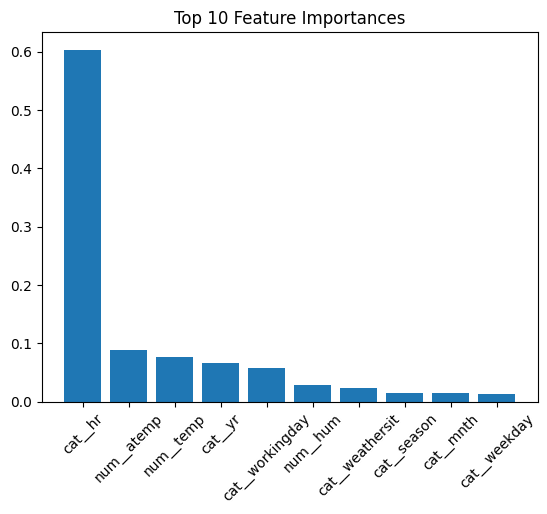

In [14]:
# Get feature names
feature_names = rf_model.named_steps['preprocessing'].get_feature_names_out()

# Get importances
importances = rf_model.named_steps['rf'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
plt.bar(importance_df['Feature'][:10], importance_df['Importance'][:10])
plt.xticks(rotation=45)
plt.title("Top 10 Feature Importances")
plt.show()

### Questions 
1.Where do tree models usually win compared to linear models?
Tree models win when relationships in the data are not straight-line relationships.

Tree models handle these kinds of patterns naturally. They are better when:

* Relationships are non-linear

* There are many complex patterns




2.What does it mean that trees can model interactions automatically?

* Tree models look at features step by step. First they check one feature, then inside that group they check another feature. Because of this, the final prediction depends on more than one feature at the same time.

So if the effect of temperature changes depending on whether it’s a working day or not, the tree can learn that automatically.

Linear regression does not do this on its own. If you want it to consider two features together, you must create a new combined feature manually.

# Residual Analysis

In [16]:
# Predict
y_pred = rf_model.predict(X_test)

# Residuals
residuals = y_test.values - y_pred

# Create DataFrame for analysis
residual_df = X_test.copy()
residual_df['actual'] = y_test.values
residual_df['predicted'] = y_pred
residual_df['residual'] = residuals

In [18]:
residual_df.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,actual,predicted,residual
0,3,1,7,0,0,0,0,1,0.76,0.7273,0.66,0.0000,149,145.45,3.55
1,3,1,7,1,0,0,0,1,0.74,0.6970,0.70,0.1343,93,109.97,-16.97
2,3,1,7,2,0,0,0,1,0.72,0.6970,0.74,0.0896,90,77.58,12.42
3,3,1,7,3,0,0,0,1,0.72,0.7121,0.84,0.1343,33,36.80,-3.80
4,3,1,7,4,0,0,0,1,0.70,0.6667,0.79,0.1940,4,9.09,-5.09


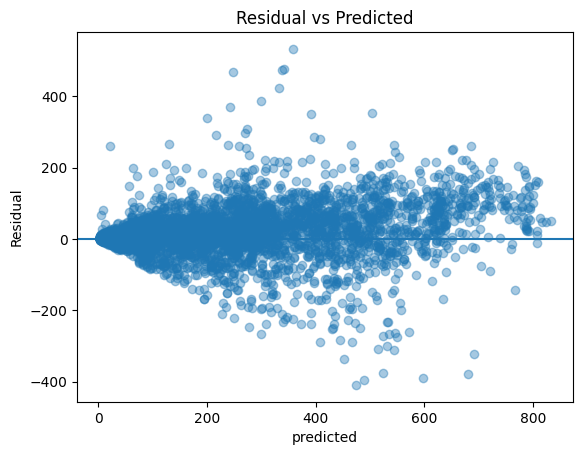

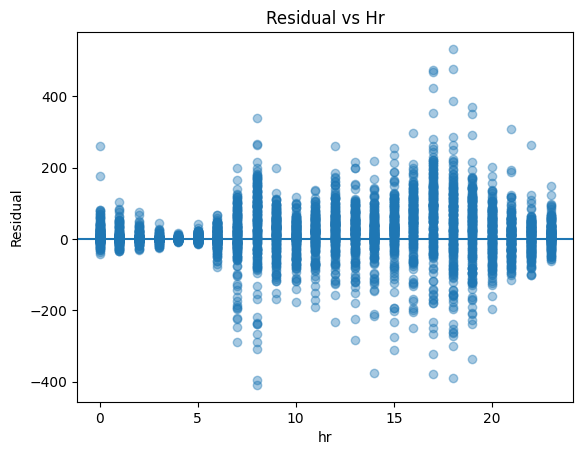

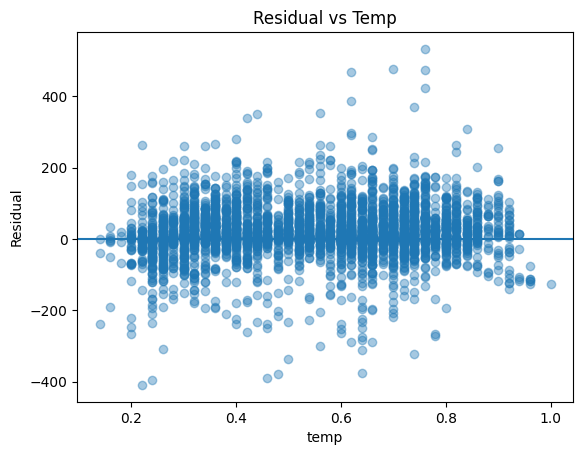

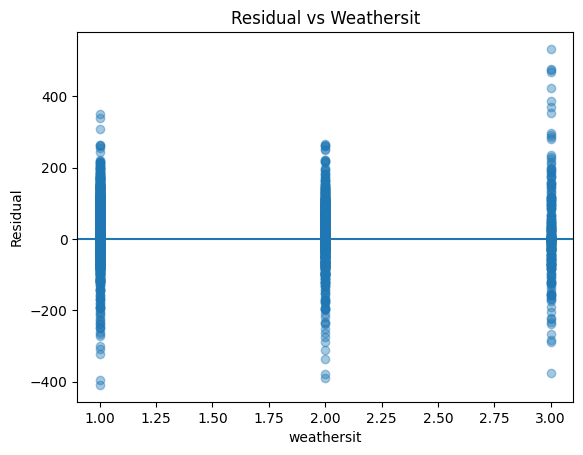

In [36]:
cols = ['predicted', 'hr', 'temp', 'weathersit']

for i in cols:
    plt.scatter(residual_df[i], residual_df['residual'], alpha=.4)
    plt.axhline(0)
    plt.xlabel(i)
    plt.ylabel("Residual")
    plt.title(f"Residual vs {i.capitalize()}")
    plt.show()

## 3 Failure Modes


**Failure Mode 1 — Peak Hours Underprediction**

     17 → 69.3

     16 → 47.6

      8  → 38.3

* Positive residual → model predicts fewer bikes than actual

* Interpretation: Random Forest underpredicts during peak commute hours (8 AM, 4–5 PM).

**Fix Tried / Proposed:**

* Add interaction hr × workingday

* Consider Gradient Boosting for sharper peaks

In [ ]:
# Make residuals
y_pred = rf_model.predict(X_test)
residuals = y_test.values - y_pred

# Combine with X_test for plotting
residual_df = X_test.copy()
residual_df['actual'] = y_test.values
residual_df['predicted'] = y_pred
residual_df['residual'] = residuals

# 1. Average residual per hour
hour_residual = residual_df.groupby('hr')['residual'].mean()
print(hour_residual)

hr
0     13.639126
1      6.914147
2      3.796923
3      0.270554
4      1.231892
5      4.078242
6      4.755714
7      5.593242
8     38.375618
9     16.864364
10     4.614121
11    12.382692
12    30.357692
13    20.884973
14    11.853169
15    29.451257
16    47.596339
17    69.297541
18    34.006776
19    29.455301
20    16.430328
21     9.024481
22     4.936776
23    14.202514
Name: residual, dtype: float64


**Failure Mode 2 — High Temperature Non-linear Error**

    0.742–0.828 → 31.18

    0.828–0.914 → 29.96

    0.914–1.0   → -29.75

* Residuals are big and flip sign at very high temp → model struggles with extreme temperatures

* Interpretation: Prediction errors are larger for high or unusual temperatures

**Fix Tried / Proposed:**

* Add polynomial feature like temp²

* Let the tree model learn these extreme cases (or tune max depth / estimators)

In [ ]:
# 3. Average residual per temp bin
residual_df['temp_bin'] = pd.cut(residual_df['temp'], bins=10)
temp_residual = residual_df.groupby('temp_bin')['residual'].mean()
print(temp_residual)

temp_bin
(0.139, 0.226]   -13.963318
(0.226, 0.312]    -0.322154
(0.312, 0.398]    24.767811
(0.398, 0.484]    21.112830
(0.484, 0.57]     24.727182
(0.57, 0.656]     13.963316
(0.656, 0.742]    19.861157
(0.742, 0.828]    31.177338
(0.828, 0.914]    29.964416
(0.914, 1.0]     -29.752619
Name: residual, dtype: float64


**Failure Mode 3 — Weather Bias**

    1 → 20.12
    2 → 13.88
    3 → 14.60

* Positive residuals → model underpredicts rentals in all weather situations

* Interpretation: Model does not fully capture how weather affects rentals

**Fix Tried / Proposed:**

* Add interaction: weather × season

* Increase model complexity (more trees or max depth)

In [ ]:
# 4. Average residual per weather
weather_residual = residual_df.groupby('weathersit')['residual'].mean()
print(weather_residual)

weathersit
1    20.125507
2    13.889969
3    14.603739
Name: residual, dtype: float64


In [43]:
peak_hours = residual_df[residual_df['hr'].isin([8,17,18])]
print(f"Mean of the peack hour is: {peak_hours['residual'].mean():.2f}")

Mean of the peack hour is: 47.24


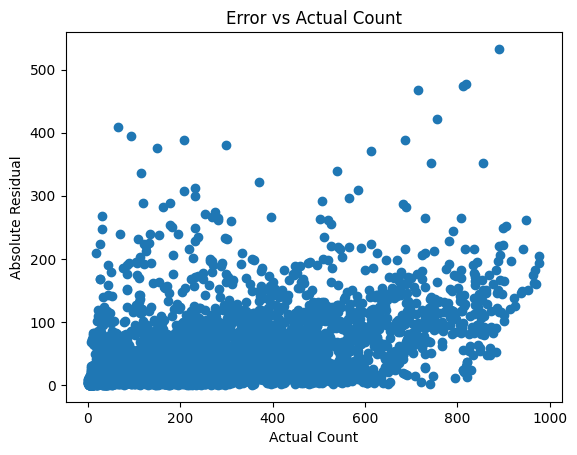

In [38]:
plt.figure()
plt.scatter(residual_df['actual'], abs(residual_df['residual']))
plt.xlabel("Actual Count")
plt.ylabel("Absolute Residual")
plt.title("Error vs Actual Count")
plt.show()

## Questions

1. Is the model underpredicting peak commute hours?

we get the peak hours's mean around 47 which is greater than zero hence the random forest model underpredicts from the actual value.

2. Does error get bigger at high counts (heteroscedasticity)? What could you do about it?

Based on the above plot as the actual count increases the absolute residual inreases as well.

**Possible Fix:**

* Log transform target y_log = np.log1p(y)

* Use models robust to high-count variance (like Gradient Boosting or tuned Random Forest)